# Introduction to APIs with PokeAPI

This notebook demonstrates various API operations using the [PokeAPI](https://pokeapi.co/) and Python's `requests` library.

## What is an API?

An **API (Application Programming Interface)** is a way for different software applications to communicate with each other. A **REST API** uses HTTP requests to access and manipulate data.


The objective of this session is to understand how data can be retrieved from a generic API.

To do so, we will use `requests` library and `json` libraries for Python. These libraries are very famous and common python libraries to deal with http request and json file serialization.

https://requests.readthedocs.io/en/latest/user/quickstart/#make-a-request

## Installing requirements

In [1]:
# Install requests library if not already installed
!pip install requests

In [5]:
import requests
import json
from pprint import pprint
import matplotlib.pyplot as plt


## 1. Basic GET Request

The most common API operation is **GET** - retrieving data from a server.

Let's get information about a pokemon

In [6]:
# Do you have a favorite Pokemon?
pokemon = "pikachu" #pikachu?

In [7]:
# Make a GET request to the PokeAPI
base_URL = "https://pokeapi.co/api/v2/pokemon/"

endpoint = base_URL + pokemon #create the full URL of the endpoint. Base_URL+ the resource we want

# We can copy and paste this URL into a web browser to see the raw JSON data returned by the API.
response = requests.get(endpoint)

# Check the status code
print(f"Status Code: {response.status_code}")
if response.status_code == 200:
    print("Request was successful!")
else:
    print("Request failed.")

Status Code: 200
Request was successful!


### Understanding Status Codes

- **200**: Success
- **404**: Not Found
- **500**: Server Error
- **401**: Unauthorized

## 2. Working with JSON Response Data

APIs typically return data in **JSON** (JavaScript Object Notation) format.

In [8]:
# Convert response to JSON 
data = response.json()

In [9]:
data

{'abilities': [{'ability': {'name': 'static',
    'url': 'https://pokeapi.co/api/v2/ability/9/'},
   'is_hidden': False,
   'slot': 1},
  {'ability': {'name': 'lightning-rod',
    'url': 'https://pokeapi.co/api/v2/ability/31/'},
   'is_hidden': True,
   'slot': 3}],
 'base_experience': 112,
 'cries': {'latest': 'https://raw.githubusercontent.com/PokeAPI/cries/main/cries/pokemon/latest/25.ogg',
  'legacy': 'https://raw.githubusercontent.com/PokeAPI/cries/main/cries/pokemon/legacy/25.ogg'},
 'forms': [{'name': 'pikachu',
   'url': 'https://pokeapi.co/api/v2/pokemon-form/25/'}],
 'game_indices': [{'game_index': 84,
   'version': {'name': 'red', 'url': 'https://pokeapi.co/api/v2/version/1/'}},
  {'game_index': 84,
   'version': {'name': 'blue', 'url': 'https://pokeapi.co/api/v2/version/2/'}},
  {'game_index': 84,
   'version': {'name': 'yellow',
    'url': 'https://pokeapi.co/api/v2/version/3/'}},
  {'game_index': 25,
   'version': {'name': 'gold', 'url': 'https://pokeapi.co/api/v2/version

In [10]:
print(data)

{'abilities': [{'ability': {'name': 'static', 'url': 'https://pokeapi.co/api/v2/ability/9/'}, 'is_hidden': False, 'slot': 1}, {'ability': {'name': 'lightning-rod', 'url': 'https://pokeapi.co/api/v2/ability/31/'}, 'is_hidden': True, 'slot': 3}], 'base_experience': 112, 'cries': {'latest': 'https://raw.githubusercontent.com/PokeAPI/cries/main/cries/pokemon/latest/25.ogg', 'legacy': 'https://raw.githubusercontent.com/PokeAPI/cries/main/cries/pokemon/legacy/25.ogg'}, 'forms': [{'name': 'pikachu', 'url': 'https://pokeapi.co/api/v2/pokemon-form/25/'}], 'game_indices': [{'game_index': 84, 'version': {'name': 'red', 'url': 'https://pokeapi.co/api/v2/version/1/'}}, {'game_index': 84, 'version': {'name': 'blue', 'url': 'https://pokeapi.co/api/v2/version/2/'}}, {'game_index': 84, 'version': {'name': 'yellow', 'url': 'https://pokeapi.co/api/v2/version/3/'}}, {'game_index': 25, 'version': {'name': 'gold', 'url': 'https://pokeapi.co/api/v2/version/4/'}}, {'game_index': 25, 'version': {'name': 'silve

In [11]:
# Print the keys available in the response
print("Available keys:")
print(data.keys())

Available keys:
dict_keys(['abilities', 'base_experience', 'cries', 'forms', 'game_indices', 'height', 'held_items', 'id', 'is_default', 'location_area_encounters', 'moves', 'name', 'order', 'past_abilities', 'past_types', 'species', 'sprites', 'stats', 'types', 'weight'])


In [12]:
# Extract specific information
print(f"Name: {data['name'].title()}")
print(f"ID: {data['id']}")
print(f"Height: {data['height']}")
print(f"Weight: {data['weight']}")
print(f"Base Experience: {data['base_experience']}")

Name: Pikachu
ID: 25
Height: 4
Weight: 60
Base Experience: 112


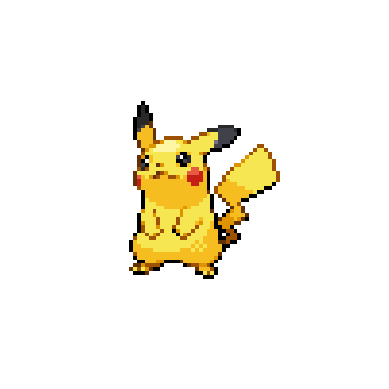

In [13]:
#plotting the sprites of the pokemon
sprite_url = data['sprites']['front_default']
img_data = requests.get(sprite_url).content
with open('sprite.png', 'wb') as handler:
    handler.write(img_data)
img = plt.imread('sprite.png')
plt.imshow(img)
plt.axis('off')
plt.show()  

## 3. Extracting Nested Data

JSON responses often contain nested structures (dictionaries within dictionaries, lists of dictionaries, etc.)

In [14]:
# Get Pokemon types
print("Types:")
for type_info in data['types']:
    print(f"  - {type_info['type']['name'].title()}")

Types:
  - Electric


In [15]:
# Get Pokemon abilities
print("Abilities:")
for ability_info in data['abilities']:
    ability_name = ability_info['ability']['name'].title()
    is_hidden = ability_info['is_hidden']
    print(f"  - {ability_name} {'(Hidden)' if is_hidden else ''}")

Abilities:
  - Static 
  - Lightning-Rod (Hidden)


In [16]:
# Get Pokemon stats
print("Stats:")
for stat_info in data['stats']:
    stat_name = stat_info['stat']['name'].upper()
    stat_value = stat_info['base_stat']
    print(f"  {stat_name}: {stat_value}")

Stats:
  HP: 35
  ATTACK: 55
  DEFENSE: 40
  SPECIAL-ATTACK: 50
  SPECIAL-DEFENSE: 50
  SPEED: 90


## 4. Query Parameters

Some API endpoints accept parameters to filter or modify the response.

In [17]:
# Get a list of Pokemon with pagination
url = "https://pokeapi.co/api/v2/pokemon"

# Parameters as a dictionary
params = {
    'limit': 10,  # Get only 10 results
    'offset': 0   # Start from the beginning
}

response = requests.get(url, params=params)
data = response.json()

print(f"Total Pokemon available: {data['count']}")
print(f"\nFirst {params['limit']} Pokemon:")
for pokemon in data['results']:
    print(f"  - {pokemon['name'].title()}")

Total Pokemon available: 1328

First 10 Pokemon:
  - Bulbasaur
  - Ivysaur
  - Venusaur
  - Charmander
  - Charmeleon
  - Charizard
  - Squirtle
  - Wartortle
  - Blastoise
  - Caterpie


In [18]:
# Get the next page of results
params = {
    'limit': 10,
    'offset': 10  # Skip the first 10
}

response = requests.get(url, params=params)
data = response.json()

print("Next 10 Pokemon:")
for pokemon in data['results']:
    print(f"  - {pokemon['name'].title()}")

Next 10 Pokemon:
  - Metapod
  - Butterfree
  - Weedle
  - Kakuna
  - Beedrill
  - Pidgey
  - Pidgeotto
  - Pidgeot
  - Rattata
  - Raticate


## 5. Working with Different Endpoints

APIs typically have multiple endpoints for different types of data.

In [19]:
# Get information about a Pokemon type
url = "https://pokeapi.co/api/v2/type/electric"
response = requests.get(url)
type_data = response.json()

print(f"Type: {type_data['name'].title()}")
print(f"\nDamage Relations:")
print(f"  Double damage to: {[t['name'] for t in type_data['damage_relations']['double_damage_to']]}")
print(f"  Half damage from: {[t['name'] for t in type_data['damage_relations']['half_damage_from']]}")
print(f"  No damage from: {[t['name'] for t in type_data['damage_relations']['no_damage_from']]}")

Type: Electric

Damage Relations:
  Double damage to: ['flying', 'water']
  Half damage from: ['flying', 'steel', 'electric']
  No damage from: []


In [20]:
# Get information about a Pokemon ability
url = "https://pokeapi.co/api/v2/ability/static"
response = requests.get(url)
ability_data = response.json()

print(f"Ability: {ability_data['name'].title()}")
print(f"\nEffect: {ability_data['effect_entries'][1]['effect']}")
print(f"\nPokemon with this ability:")
for pokemon in ability_data['pokemon'][:5]:  # Show first 5
    print(f"  - {pokemon['pokemon']['name'].title()}")

Ability: Static

Effect: Whenever a move makes contact with this Pokémon, the move's user has a 30% chance of being paralyzed.

Pokémon that are immune to electric-type moves can still be paralyzed by this ability.

Overworld: If the lead Pokémon has this ability, there is a 50% chance that encounters will be with an electric Pokémon, if applicable.

Pokemon with this ability:
  - Pikachu
  - Raichu
  - Voltorb
  - Electrode
  - Electabuzz


## 6. Making Multiple Requests

Sometimes you need to combine data from multiple API calls.

In [21]:
# Get detailed info for multiple Pokemon
pokemon_names = ['bulbasaur', 'charmander', 'squirtle']

print("Starter Pokemon Comparison:\n")
for name in pokemon_names:
    url = f"https://pokeapi.co/api/v2/pokemon/{name}"
    response = requests.get(url)
    data = response.json()
    
    print(f"{data['name'].title()}:")
    print(f"  Type: {', '.join([t['type']['name'] for t in data['types']])}")
    print(f"  HP: {[s['base_stat'] for s in data['stats'] if s['stat']['name'] == 'hp'][0]}")
    print(f"  Attack: {[s['base_stat'] for s in data['stats'] if s['stat']['name'] == 'attack'][0]}")
    print()

Starter Pokemon Comparison:

Bulbasaur:
  Type: grass, poison
  HP: 45
  Attack: 49

Charmander:
  Type: fire
  HP: 39
  Attack: 52

Squirtle:
  Type: water
  HP: 44
  Attack: 48



## 7. Complete Example: Pokemon Stats Analyzer

In [22]:
class PokemonAnalyzer:
    BASE_URL = "https://pokeapi.co/api/v2"
    
    def __init__(self):
        self.session = requests.Session()
    
    def get_pokemon(self, name_or_id):
        """Get Pokemon data by name or ID"""
        url = f"{self.BASE_URL}/pokemon/{name_or_id}"
        try:
            response = self.session.get(url, timeout=5)
            response.raise_for_status()
            return response.json()
        except requests.exceptions.RequestException as e:
            print(f"Error fetching Pokemon: {e}")
            return None
    
    def get_stats_summary(self, pokemon_name):
        """Get a formatted summary of Pokemon stats"""
        data = self.get_pokemon(pokemon_name)
        if not data:
            return None
        
        stats = {stat['stat']['name']: stat['base_stat'] for stat in data['stats']}
        types = [t['type']['name'] for t in data['types']]
        
        return {
            'name': data['name'],
            'id': data['id'],
            'types': types,
            'stats': stats,
            'total': sum(stats.values())
        }
    
    def compare_pokemon(self, pokemon1, pokemon2):
        """Compare two Pokemon"""
        p1 = self.get_stats_summary(pokemon1)
        p2 = self.get_stats_summary(pokemon2)
        
        if not p1 or not p2:
            return
        
        print(f"\n{'='*60}")
        print(f"Comparing {p1['name'].title()} vs {p2['name'].title()}")
        print(f"{'='*60}\n")
        
        print(f"{'Stat':<15} {p1['name'].title():<15} {p2['name'].title():<15} {'Winner':<15}")
        print("-" * 60)
        
        for stat in p1['stats'].keys():
            v1, v2 = p1['stats'][stat], p2['stats'][stat]
            winner = p1['name'].title() if v1 > v2 else (p2['name'].title() if v2 > v1 else "Tie")
            print(f"{stat.upper():<15} {v1:<15} {v2:<15} {winner:<15}")
        
        print("-" * 60)
        print(f"{'TOTAL':<15} {p1['total']:<15} {p2['total']:<15} "
              f"{p1['name'].title() if p1['total'] > p2['total'] else p2['name'].title()}")
    
    def close(self):
        """Close the session"""
        self.session.close()

In [23]:
# Use the analyzer
analyzer = PokemonAnalyzer()

# Compare two Pokemon
p1 = 'pikachu'
p2 = 'raichu'

analyzer.compare_pokemon(p1, p2)

analyzer.close()


Comparing Pikachu vs Raichu

Stat            Pikachu         Raichu          Winner         
------------------------------------------------------------
HP              35              60              Raichu         
ATTACK          55              90              Raichu         
DEFENSE         40              55              Raichu         
SPECIAL-ATTACK  50              90              Raichu         
SPECIAL-DEFENSE 50              80              Raichu         
SPEED           90              110             Raichu         
------------------------------------------------------------
TOTAL           320             485             Raichu


## 8. Excercises to practice

1. Get information about your favorite Pokemon and print its types and abilities
2. Create a function that finds all Pokemon of a specific type (e.g., "fire")
3. Build a function that finds the Pokemon with the highest base stat total in a given generation
4. Create a simple Pokemon recommendation system that suggests Pokemon based on desired types and minimum stats